In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df = pd.read_csv("C:\\Users\\jiyad\\OneDrive\\Documents\\Desktop\\Dataset for ML\\networkadds.csv")

In [54]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [55]:
df = df.drop('Gender', axis = 1)

In [56]:
df.drop('User ID', axis = 1)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


# train_test_split

In [58]:

X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.3, random_state = 4)

In [59]:
X_train.shape

(280, 2)

In [60]:
X_train.shape, X_test.shape

((280, 2), (120, 2))

# Standadization

In [61]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#fir the scaleto the train set, it will learn the parameters
scaler.fit(X_train)

# Transform train test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
scaler.mean_

array([3.78464286e+01, 7.07035714e+04])

In [63]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

In [65]:
X_test_scaled

,Age,EstimatedSalary
0,-0.465929,-0.315151
1,-1.042761,0.391494
2,-1.235038,0.479824
3,0.014764,-0.609586
4,-1.042761,0.509268
...,...,...
115,1.841398,-0.315151
116,-0.273652,0.038171
117,1.264566,2.216991
118,0.976150,0.097058


In [66]:
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.8,70703.6
std,10.4,34024.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,71000.0
75%,46.0,89000.0
max,60.0,150000.0


In [67]:
# mean would always 0 and standard deviation would be 1 after converting the standidazation
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,-0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.1,2.3


# Effect  of Scalling

<function matplotlib.pyplot.show(close=None, block=None)>

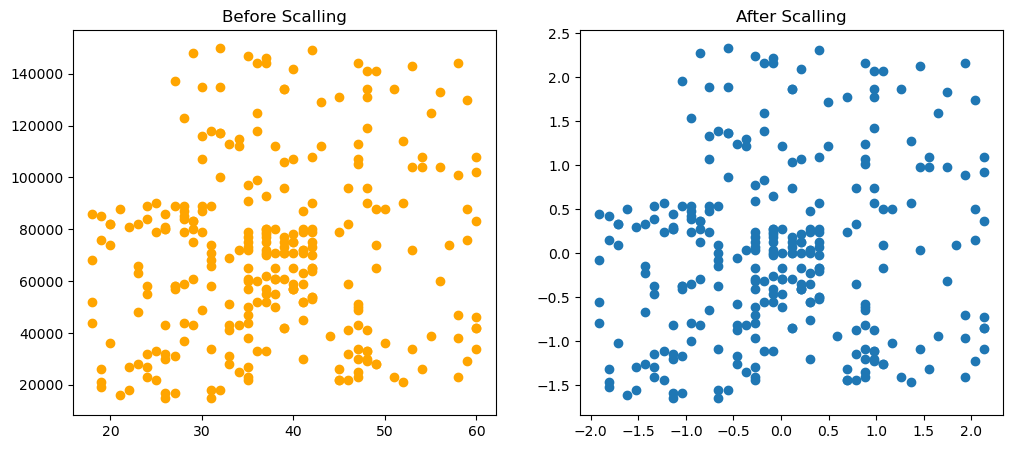

In [75]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'], color  = "orange")
ax1.set_title("Before Scalling")

ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'])
ax2.set_title("After Scalling")
plt.show

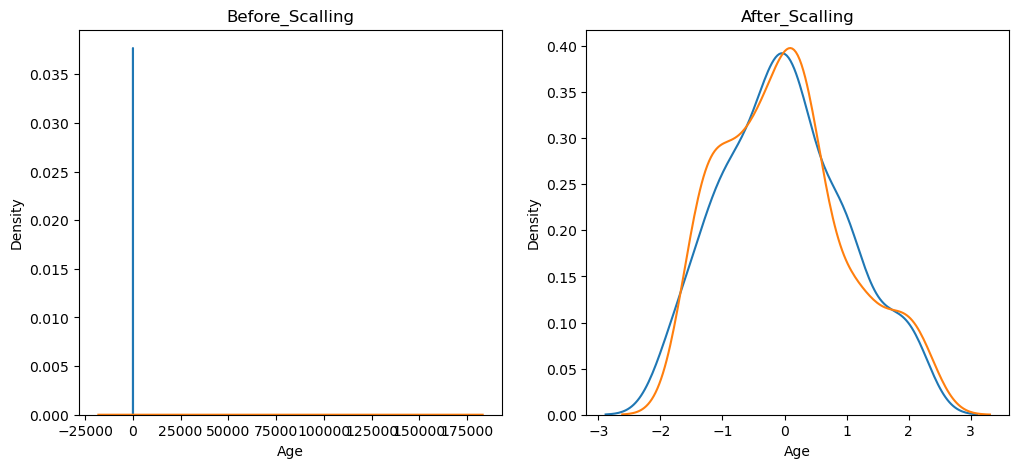

In [79]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

#before scalling
ax1.set_title("Before_Scalling")
sns.kdeplot(X_train['Age'], ax = ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax = ax1)

#after scalling
ax2.set_title("After_Scalling")
sns.kdeplot(X_train_scaled['Age'], ax = ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax = ax2)
plt.show()

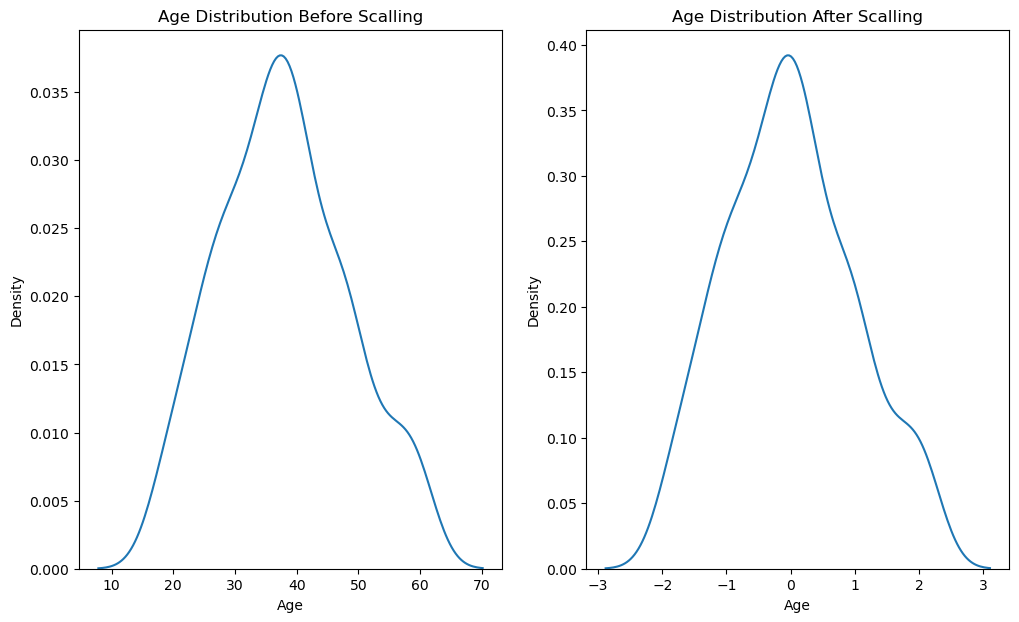

In [84]:
# Comparition of Distribution

fig, (ax1, ax2)= plt.subplots(ncols  = 2, figsize = (12, 7))

#before scalling
ax1.set_title("Age Distribution Before Scalling")
sns.kdeplot(X_train['Age'], ax = ax1)

# after scalling
ax2.set_title("Age Distribution After Scalling")
sns.kdeplot(X_train_scaled['Age'], ax = ax2)
plt.show()

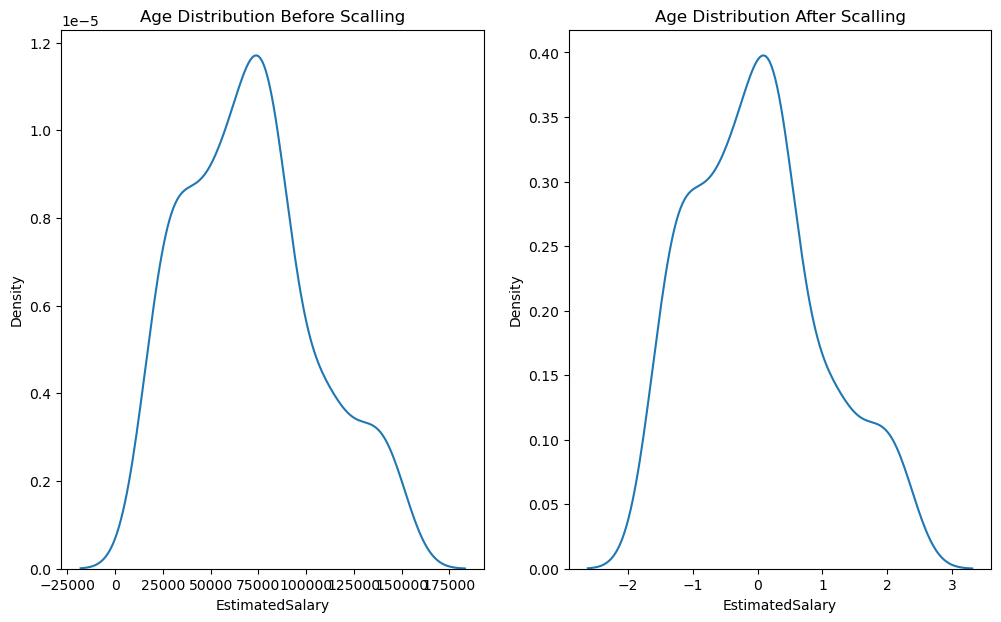

In [85]:
fig, (ax1, ax2)= plt.subplots(ncols  = 2, figsize = (12, 7))

#before scalling
ax1.set_title("Age Distribution Before Scalling")
sns.kdeplot(X_train['EstimatedSalary'], ax = ax1)

# after scalling
ax2.set_title("Age Distribution After Scalling")
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax = ax2)
plt.show()

# why scalling is important?

In [88]:
from sklearn.linear_model import LogisticRegression
Ir = LogisticRegression()
Ir_scaled = LogisticRegression()

In [92]:
Ir.fit(X_train, y_train)
Ir_scaled.fit(X_train_scaled, y_train)

LogisticRegression()

In [95]:
y_pred = Ir.predict(X_test)
y_pred_scaled = Ir_scaled.predict(X_test_scaled)

In [96]:
from sklearn.metrics import accuracy_score

In [98]:
print("Actual", accuracy_score(y_test, y_pred))
print("Scaled", accuracy_score(y_test, y_pred_scaled))

Actual 0.8833333333333333
Scaled 0.8833333333333333
